In [13]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

### Read in adata

In [14]:
adata = sc.read_h5ad('/home/workspace/private/working/combined_data_030526.h5ad')
adata

AnnData object with n_obs × n_vars = 4374290 × 53
    obs: 'cell_id', 'sample_id', 'Timeframe', 'batch_id', 'x', 'y', 'Outline Area (µm²)', 'Perimeter (µm)', 'Circularity'
    var: 'marker_name'
    layers: 'intensity_mean', 'intensity_median', 'intensity_std'

### Assess the distribution of by markers (cell count x intensity)

In [4]:
# Visiualize distributions

def plot_marker_distributions(adata, bins=100, figsize_per_marker=(5, 3)):
    """
    Plot distribution for each marker: intensity on x-axis, cell count on y-axis.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with intensity data
    bins : int
        Number of bins for histogram (default: 100)
    figsize_per_marker : tuple
        Size of each subplot (default: (5, 3))
    """
    
    # Get data
    if sparse.issparse(adata.X):
        X_data = adata.X.toarray()
    else:
        X_data = adata.X
    
    marker_names = adata.var['marker_name'].values
    n_markers = len(marker_names)
    
    # Calculate grid dimensions
    n_cols = 4
    n_rows = int(np.ceil(n_markers / n_cols))
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, 
                             figsize=(figsize_per_marker[0] * n_cols, 
                                     figsize_per_marker[1] * n_rows))
    axes = axes.flatten()
    
    print(f"Creating distribution plots for {n_markers} markers...")
    
    for idx, marker in enumerate(marker_names):
        ax = axes[idx]
        data = X_data[:, idx]
        
        # Remove NaN values for plotting
        valid_data = data[~np.isnan(data)]
        
        if len(valid_data) == 0:
            ax.text(0.5, 0.5, 'No valid data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(marker, fontsize=10, fontweight='bold')
            continue
        
        # Calculate statistics
        mean_val = np.mean(valid_data)
        median_val = np.median(valid_data)
        max_val = np.max(valid_data)
        
        # Plot histogram
        counts, bin_edges, patches = ax.hist(valid_data, bins=bins, 
                                             color='steelblue', alpha=0.7, 
                                             edgecolor='black', linewidth=0.5)
        
        # Add vertical lines for statistics
        ax.axvline(median_val, color='red', linestyle='--', 
                  linewidth=2, label=f'Median: {median_val:.1f}', alpha=0.7)
        ax.axvline(mean_val, color='orange', linestyle='--', 
                  linewidth=2, label=f'Mean: {mean_val:.1f}', alpha=0.7)
        
        # Formatting
        ax.set_xlabel('Intensity', fontsize=9)
        ax.set_ylabel('Number of Cells', fontsize=9)
        ax.set_title(marker, fontsize=10, fontweight='bold')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=8)
        
        # Add stats box
        n_cells = len(valid_data)
        n_nan = len(data) - len(valid_data)
        stats_text = f'n={n_cells:,}'
        if n_nan > 0:
            stats_text += f'\nNaN={n_nan:,}'
        stats_text += f'\nMax={max_val:.1f}'
        
        ax.text(0.98, 0.98, stats_text, 
               transform=ax.transAxes, fontsize=7,
               verticalalignment='top', horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # Hide unused subplots
    for idx in range(n_markers, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('marker_distributions_all.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: marker_distributions_all.png")
    plt.show()


def plot_marker_distributions_log_scale(adata, bins=100, figsize_per_marker=(5, 3)):
    """
    Same as above but with log scale on y-axis to better see tail of distribution.
    """
    
    # Get data
    if sparse.issparse(adata.X):
        X_data = adata.X.toarray()
    else:
        X_data = adata.X
    
    marker_names = adata.var['marker_name'].values
    n_markers = len(marker_names)
    
    # Calculate grid dimensions
    n_cols = 4
    n_rows = int(np.ceil(n_markers / n_cols))
    
    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, 
                             figsize=(figsize_per_marker[0] * n_cols, 
                                     figsize_per_marker[1] * n_rows))
    axes = axes.flatten()
    
    print(f"Creating log-scale distribution plots for {n_markers} markers...")
    
    for idx, marker in enumerate(marker_names):
        ax = axes[idx]
        data = X_data[:, idx]
        
        # Remove NaN values for plotting
        valid_data = data[~np.isnan(data)]
        
        if len(valid_data) == 0:
            ax.text(0.5, 0.5, 'No valid data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(marker, fontsize=10, fontweight='bold')
            continue
        
        # Calculate statistics
        median_val = np.median(valid_data)
        p95 = np.percentile(valid_data, 95)
        p99 = np.percentile(valid_data, 99)
        max_val = np.max(valid_data)
        
        # Plot histogram
        counts, bin_edges, patches = ax.hist(valid_data, bins=bins, 
                                             color='steelblue', alpha=0.7, 
                                             edgecolor='black', linewidth=0.5)
        
        # Add vertical lines for percentiles
        ax.axvline(median_val, color='green', linestyle='--', 
                  linewidth=1.5, label=f'Median: {median_val:.1f}', alpha=0.7)
        ax.axvline(p95, color='orange', linestyle='--', 
                  linewidth=1.5, label=f'P95: {p95:.1f}', alpha=0.7)
        ax.axvline(p99, color='red', linestyle='--', 
                  linewidth=1.5, label=f'P99: {p99:.1f}', alpha=0.7)
        
        # Set log scale
        ax.set_yscale('log')
        
        # Formatting
        ax.set_xlabel('Intensity', fontsize=9)
        ax.set_ylabel('Number of Cells (log scale)', fontsize=9)
        ax.set_title(marker, fontsize=10, fontweight='bold')
        ax.legend(fontsize=6, loc='upper right')
        ax.grid(True, alpha=0.3, which='both')
        ax.tick_params(labelsize=8)
    
    # Hide unused subplots
    for idx in range(n_markers, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('marker_distributions_log_scale.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: marker_distributions_log_scale.png")
    plt.show()


def plot_single_marker_detailed(adata, marker_name):
    """
    Detailed plot for a single marker with both linear and log scale.
    """
    
    # Get data
    if sparse.issparse(adata.X):
        X_data = adata.X.toarray()
    else:
        X_data = adata.X
    
    marker_names = adata.var['marker_name'].values
    
    if marker_name not in marker_names:
        print(f"Error: Marker '{marker_name}' not found")
        return
    
    marker_idx = list(marker_names).index(marker_name)
    data = X_data[:, marker_idx]
    valid_data = data[~np.isnan(data)]
    
    # Calculate statistics
    mean_val = np.mean(valid_data)
    median_val = np.median(valid_data)
    std_val = np.std(valid_data)
    min_val = np.min(valid_data)
    max_val = np.max(valid_data)
    p95 = np.percentile(valid_data, 95)
    p99 = np.percentile(valid_data, 99)
    p999 = np.percentile(valid_data, 99.9)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale
    ax1.hist(valid_data, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
    ax1.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax1.axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax1.axvline(p95, color='orange', linestyle=':', linewidth=2, label=f'P95: {p95:.1f}')
    ax1.axvline(p99, color='red', linestyle=':', linewidth=2, label=f'P99: {p99:.1f}')
    ax1.axvline(p999, color='darkred', linestyle=':', linewidth=2, label=f'P99.9: {p999:.1f}')
    
    ax1.set_xlabel('Intensity', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Cells', fontsize=12, fontweight='bold')
    ax1.set_title(f'{marker_name} - Linear Scale', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Log scale
    ax2.hist(valid_data, bins=100, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    ax2.axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    ax2.axvline(p95, color='orange', linestyle=':', linewidth=2, label=f'P95: {p95:.1f}')
    ax2.axvline(p99, color='red', linestyle=':', linewidth=2, label=f'P99: {p99:.1f}')
    ax2.axvline(p999, color='darkred', linestyle=':', linewidth=2, label=f'P99.9: {p999:.1f}')
    
    ax2.set_xlabel('Intensity', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Cells (log scale)', fontsize=12, fontweight='bold')
    ax2.set_title(f'{marker_name} - Log Scale', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3, which='both')
    
    # Stats box
    stats_text = (f'Statistics:\n'
                 f'n = {len(valid_data):,}\n'
                 f'Min = {min_val:.2f}\n'
                 f'Max = {max_val:.2f}\n'
                 f'Mean = {mean_val:.2f}\n'
                 f'Median = {median_val:.2f}\n'
                 f'Std = {std_val:.2f}\n'
                 f'P95 = {p95:.2f}\n'
                 f'P99 = {p99:.2f}\n'
                 f'P99.9 = {p999:.2f}')
    
    fig.text(0.02, 0.98, stats_text, transform=fig.transFigure,
            fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout(rect=[0.12, 0, 1, 1])
    plt.savefig(f'distribution_{marker_name}.png', dpi=300, bbox_inches='tight')
    print(f"✓ Saved: distribution_{marker_name}.png")
    plt.show()

'''
# Usage:

# Plot all markers (linear scale)
plot_marker_distributions(adata, bins=100)

# Plot all markers (log scale - better for seeing tails)
plot_marker_distributions_log_scale(adata, bins=100)

# Plot single marker in detail
plot_single_marker_detailed(adata, 'CD3d-EP4426AF647')
plot_single_marker_detailed(adata, 'CD452B11PD726AF750')

'''

"\n# Usage:\n\n# Plot all markers (linear scale)\nplot_marker_distributions(adata, bins=100)\n\n# Plot all markers (log scale - better for seeing tails)\nplot_marker_distributions_log_scale(adata, bins=100)\n\n# Plot single marker in detail\nplot_single_marker_detailed(adata, 'CD3d-EP4426AF647')\nplot_single_marker_detailed(adata, 'CD452B11PD726AF750')\n\n"

Creating distribution plots for 53 markers...
✓ Saved: marker_distributions_all.png


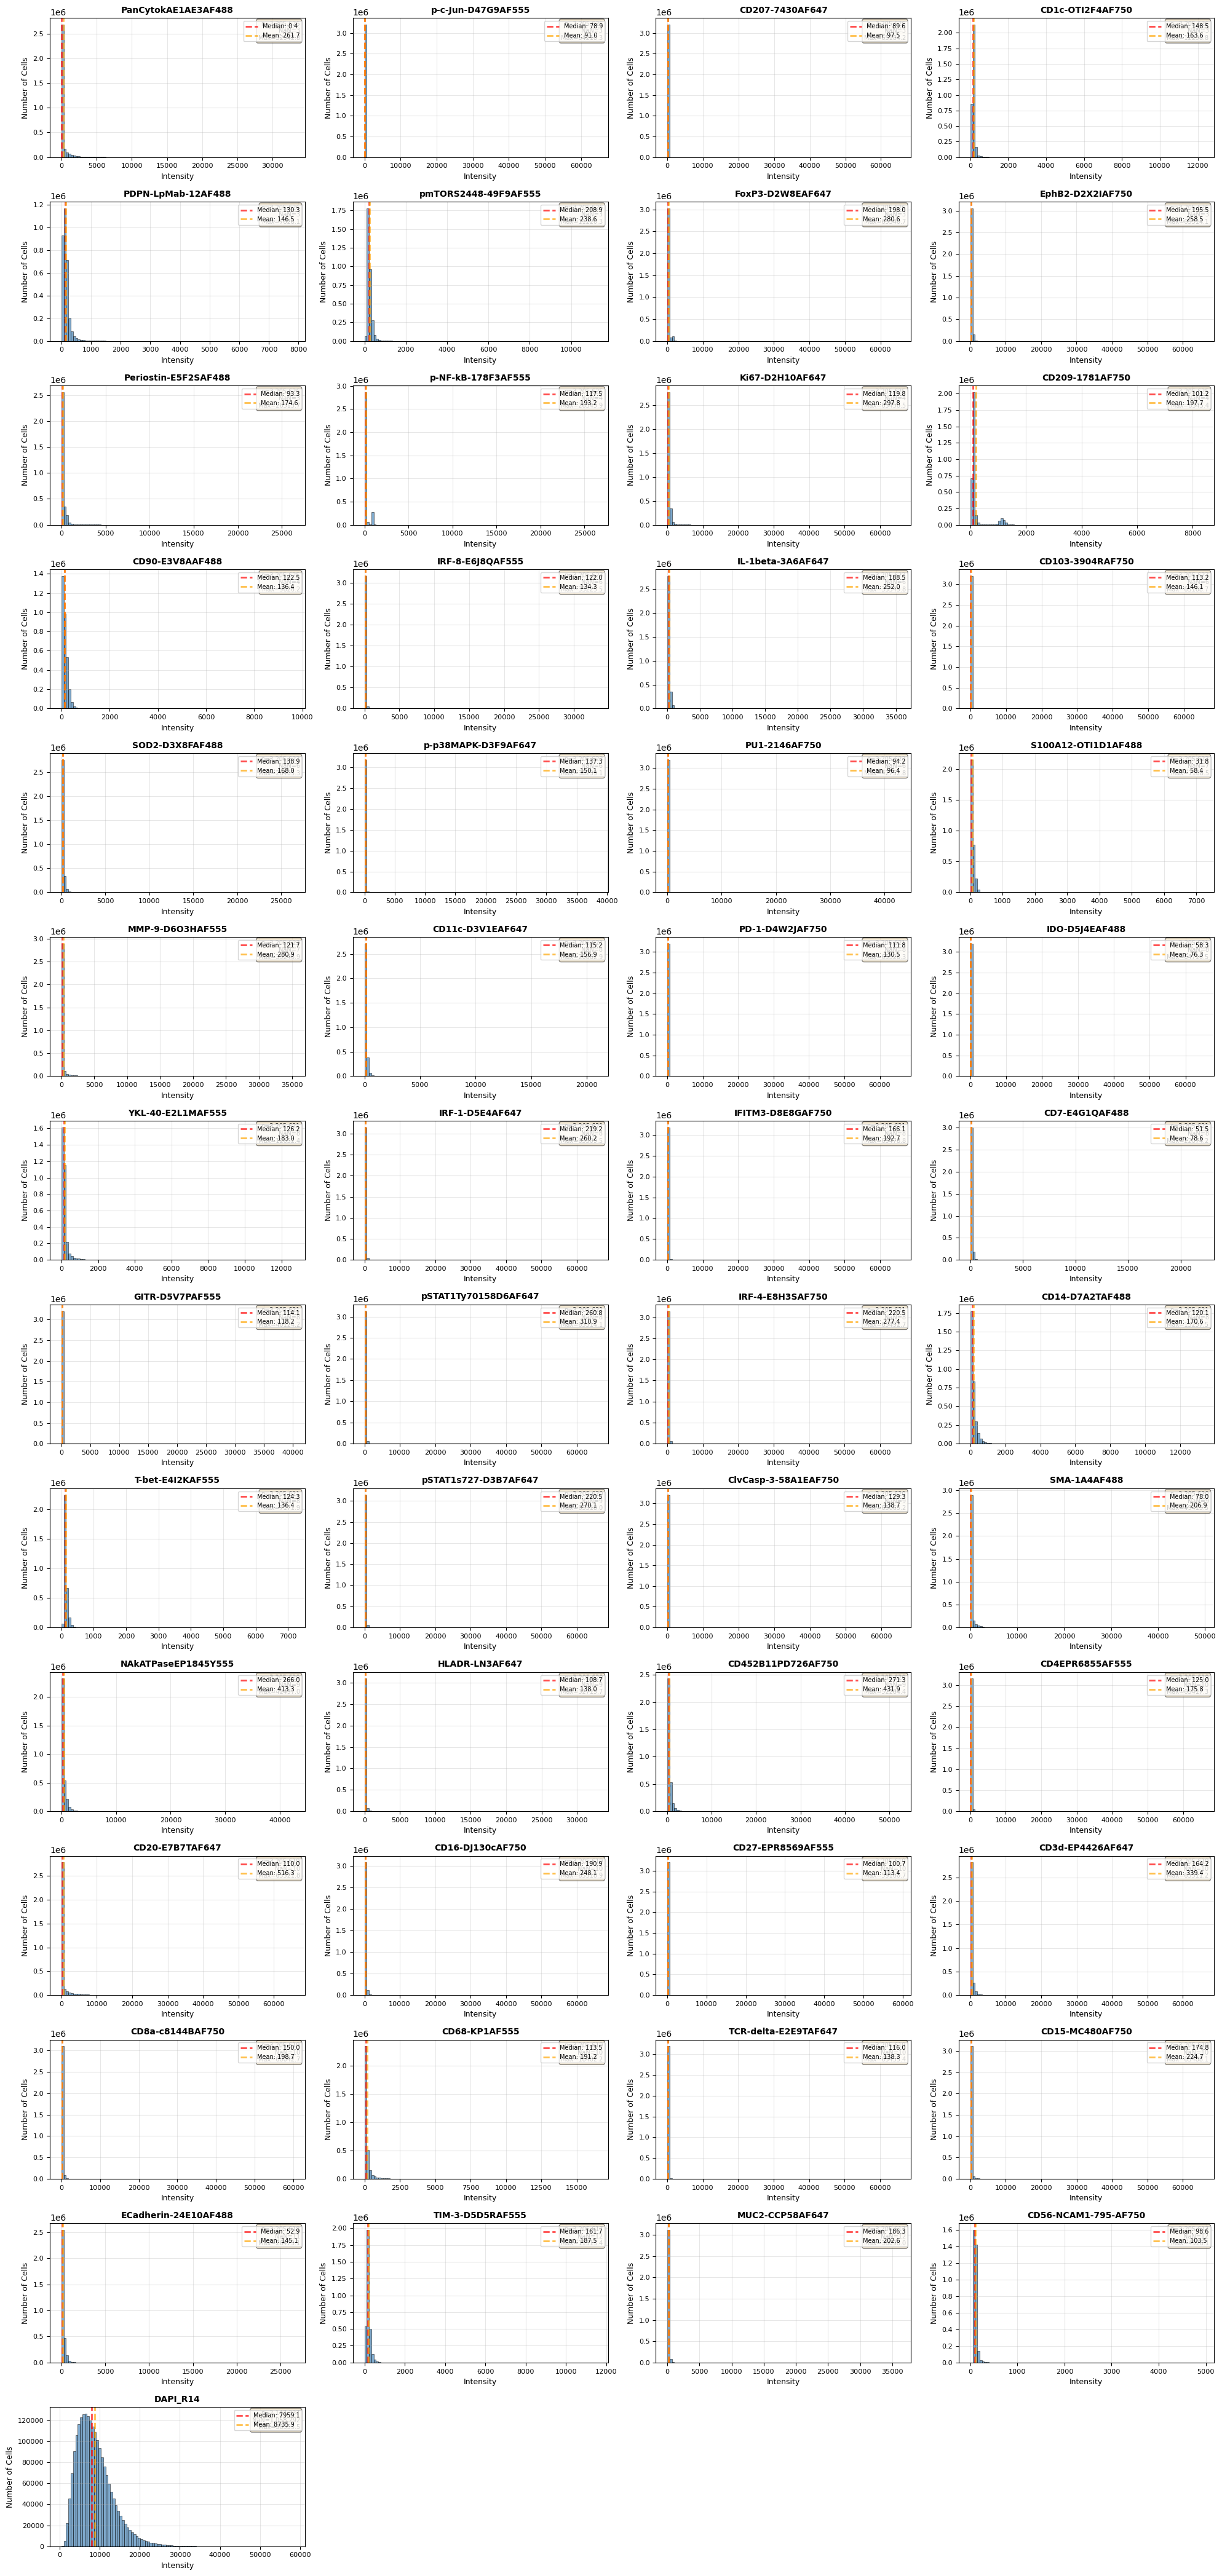

In [5]:
plot_marker_distributions(adata, bins=100)

In [10]:
# Remove max values

def remove_max_intensity_values(adata, inplace=True):
    """
    Remove (set to NaN) all measurements that are at the maximum intensity 
    for each marker. This removes detector-saturated values.
    
    Parameters:
    -----------
    adata : AnnData
        AnnData object with intensity data
    inplace : bool
        If True, modifies adata in place; if False, returns a copy
    
    Returns:
    --------
    If inplace=True: statistics dictionary
    If inplace=False: (modified adata, statistics dictionary)
    """
    
    if not inplace:
        adata = adata.copy()
    
    # Get data
    if sparse.issparse(adata.X):
        X_data = adata.X.toarray()
    else:
        X_data = adata.X.copy()
    
    marker_names = adata.var['marker_name'].values
    
    removal_stats = {
        'by_marker': {},
        'total_removed': 0
    }
    
    print("="*80)
    print("REMOVING MAXIMUM INTENSITY VALUES (DETECTOR SATURATION)")
    print("="*80)
    print(f"Strategy: Set all values at max intensity to NaN for each marker\n")
    
    for idx, marker in enumerate(marker_names):
        marker_intensity = X_data[:, idx]
        
        # Find maximum value (ignoring existing NaN)
        valid_data = marker_intensity[~np.isnan(marker_intensity)]
        
        if len(valid_data) == 0:
            print(f"⊘ Skipping {marker}: no valid data")
            continue
        
        max_val = np.max(valid_data)
        
        # Find cells at max value
        at_max_mask = marker_intensity == max_val
        n_at_max = np.sum(at_max_mask)
        
        if n_at_max > 0:
            pct_at_max = 100 * n_at_max / len(marker_intensity)
            
            # Set to NaN
            X_data[at_max_mask, idx] = np.nan
            
            # Calculate new max after removal
            remaining_data = marker_intensity[~at_max_mask]
            remaining_data = remaining_data[~np.isnan(remaining_data)]
            new_max = np.max(remaining_data) if len(remaining_data) > 0 else np.nan
            
            removal_stats['by_marker'][marker] = {
                'old_max': max_val,
                'new_max': new_max,
                'n_removed': n_at_max,
                'pct_removed': pct_at_max,
                'n_remaining': len(remaining_data)
            }
            removal_stats['total_removed'] += n_at_max
            
            print(f"{marker}:")
            print(f"  Max value: {max_val:.2f}")
            print(f"  Removed: {n_at_max:,} cells ({pct_at_max:.3f}%)")
            print(f"  New max: {new_max:.2f}")
            print(f"  Remaining valid: {len(remaining_data):,}")
        else:
            print(f"✓ {marker}: no cells at max value")
    
    # Update adata.X
    adata.X = X_data
    
        # Update layers
    for layer in ['intensity_mean', 'intensity_median', 'intensity_std']:
        if layer in adata.layers:
            layer_data = adata.layers[layer]
            if sparse.issparse(layer_data):
                layer_data = layer_data.toarray()
            else:
                layer_data = layer_data.copy()
            
            for idx, marker in enumerate(marker_names):
                marker_layer_data = layer_data[:, idx]
                valid = marker_layer_data[~np.isnan(marker_layer_data)]
                
                if len(valid) == 0:
                    continue
            
                layer_max = np.max(valid)
                at_max_mask = marker_layer_data == layer_max
                layer_data[at_max_mask, idx] = np.nan
        
            adata.layers[layer] = layer_data
            print(f"✓ Updated layer: {layer}")
    
    # Summary
    total_measurements = adata.n_obs * adata.n_vars
    print(f"\n{'='*80}")
    print("REMOVAL SUMMARY")
    print("="*80)
    print(f"Markers affected: {len(removal_stats['by_marker'])} / {len(marker_names)}")
    print(f"Total measurements removed: {removal_stats['total_removed']:,}")
    print(f"Percentage of dataset: {100*removal_stats['total_removed']/total_measurements:.4f}%")
    
    if not inplace:
        return adata, removal_stats
    return removal_stats


def remove_top_n_intensity_values(adata, n_values=1, inplace=True):
    """
    Remove the top N unique intensity values for each marker.
    Useful if saturation creates multiple pile-up points.
    
    Parameters:
    -----------
    adata : AnnData
    n_values : int
        Number of top unique intensity values to remove (default: 1)
    inplace : bool
        If True, modifies adata in place
    
    Returns:
    --------
    If inplace=True: statistics dictionary
    If inplace=False: (modified adata, statistics dictionary)
    """
    
    if not inplace:
        adata = adata.copy()
    
    # Get data
    if sparse.issparse(adata.X):
        X_data = adata.X.toarray()
    else:
        X_data = adata.X.copy()
    
    marker_names = adata.var['marker_name'].values
    
    removal_stats = {
        'by_marker': {},
        'total_removed': 0
    }
    
    print("="*80)
    print(f"REMOVING TOP {n_values} UNIQUE INTENSITY VALUE(S)")
    print("="*80)
    
    for idx, marker in enumerate(marker_names):
        marker_intensity = X_data[:, idx]
        
        # Get unique values (excluding NaN)
        valid_data = marker_intensity[~np.isnan(marker_intensity)]
        
        if len(valid_data) == 0:
            print(f"⊘ Skipping {marker}: no valid data")
            continue
        
        # Get top N unique values
        unique_values = np.unique(valid_data)
        if len(unique_values) <= n_values:
            print(f"⚠️  {marker}: only {len(unique_values)} unique values, skipping")
            continue
        
        top_n_values = np.sort(unique_values)[-n_values:]
        
        # Remove cells with these values
        remove_mask = np.isin(marker_intensity, top_n_values)
        n_removed = np.sum(remove_mask)
        
        if n_removed > 0:
            pct_removed = 100 * n_removed / len(marker_intensity)
            
            # Set to NaN
            X_data[remove_mask, idx] = np.nan
            
            # New max
            remaining_data = marker_intensity[~remove_mask]
            remaining_data = remaining_data[~np.isnan(remaining_data)]
            new_max = np.max(remaining_data) if len(remaining_data) > 0 else np.nan
            
            removal_stats['by_marker'][marker] = {
                'removed_values': top_n_values.tolist(),
                'new_max': new_max,
                'n_removed': n_removed,
                'pct_removed': pct_removed
            }
            removal_stats['total_removed'] += n_removed
            
            print(f"{marker}:")
            print(f"  Removed values: {top_n_values}")
            print(f"  Cells removed: {n_removed:,} ({pct_removed:.3f}%)")
            print(f"  New max: {new_max:.2f}")
    
    # Update adata
    adata.X = X_data
    
    # Update layers
    for layer in ['intensity_mean', 'intensity_median', 'intensity_std']:
        if layer in adata.layers:
            layer_data = adata.layers[layer]
            if sparse.issparse(layer_data):
                layer_data = layer_data.toarray()
            else:
                layer_data = layer_data.copy()
            
            for marker, stats in removal_stats['by_marker'].items():
                marker_idx = list(marker_names).index(marker)
                removed_values = stats['removed_values']
                remove_mask = np.isin(layer_data[:, marker_idx], removed_values)
                layer_data[remove_mask, marker_idx] = np.nan
            
            adata.layers[layer] = layer_data
    
    total_measurements = adata.n_obs * adata.n_vars
    print(f"\n{'='*80}")
    print("REMOVAL SUMMARY")
    print("="*80)
    print(f"Markers affected: {len(removal_stats['by_marker'])} / {len(marker_names)}")
    print(f"Total measurements removed: {removal_stats['total_removed']:,}")
    print(f"Percentage of dataset: {100*removal_stats['total_removed']/total_measurements:.4f}%")
    
    if not inplace:
        return adata, removal_stats
    return removal_stats

### Replace all NaNs with zero

In [15]:
import numpy as np
from scipy import sparse

# Replace NaNs with 0 in adata.X
X_data = adata.X.toarray() if sparse.issparse(adata.X) else adata.X.copy()
X_data[np.isnan(X_data)] = 0
adata.X = X_data

# Replace NaNs with 0 in all layers
for layer_name in adata.layers:
    layer_data = adata.layers[layer_name]
    layer_data = layer_data.toarray() if sparse.issparse(layer_data) else layer_data.copy()
    layer_data[np.isnan(layer_data)] = 0
    adata.layers[layer_name] = layer_data
    print(f"✓ Replaced NaNs in layer: {layer_name}")

print(f"\n✓ Done. Remaining NaNs in adata.X: {np.sum(np.isnan(adata.X))}")

✓ Replaced NaNs in layer: intensity_mean
✓ Replaced NaNs in layer: intensity_median
✓ Replaced NaNs in layer: intensity_std

✓ Done. Remaining NaNs in adata.X: 0


### Remove data that reaches the detector limit (the max intensity value)

In [11]:
removal_stats = remove_max_intensity_values(adata, inplace=True)

# After removal, check the results
from scipy import sparse
X_data = adata.X.toarray() if sparse.issparse(adata.X) else adata.X
print("\n" + "="*80)
print("POST-REMOVAL CHECK")
print("="*80)
for idx, marker in enumerate(adata.var['marker_name'].values):
    data = X_data[:, idx]
    valid = data[~np.isnan(data)]
    n_nan = np.sum(np.isnan(data))
    if len(valid) > 0:
        print(f"{marker}: max={np.max(valid):.2f}, NaNs={n_nan:,}")

REMOVING MAXIMUM INTENSITY VALUES (DETECTOR SATURATION)
Strategy: Set all values at max intensity to NaN for each marker

PanCytokAE1AE3AF488:
  Max value: 32942.82
  Removed: 1 cells (0.000%)
  New max: 27712.55
  Remaining valid: 4,374,289
p-c-Jun-D47G9AF555:
  Max value: 64218.33
  Removed: 1 cells (0.000%)
  New max: 64194.88
  Remaining valid: 4,374,289
CD207-7430AF647:
  Max value: 65184.20
  Removed: 1 cells (0.000%)
  New max: 65144.64
  Remaining valid: 4,374,289
CD1c-OTI2F4AF750:
  Max value: 12238.82
  Removed: 1 cells (0.000%)
  New max: 11492.72
  Remaining valid: 4,374,289
PDPN-LpMab-12AF488:
  Max value: 9287.43
  Removed: 1 cells (0.000%)
  New max: 8994.28
  Remaining valid: 4,374,289
pmTORS2448-49F9AF555:
  Max value: 11220.32
  Removed: 1 cells (0.000%)
  New max: 9420.05
  Remaining valid: 4,374,289
FoxP3-D2W8EAF647:
  Max value: 65340.69
  Removed: 1 cells (0.000%)
  New max: 65289.82
  Remaining valid: 4,374,289
EphB2-D2X2IAF750:
  Max value: 65514.11
  Removed: 1

# Remove any Cells that contains a NaN in any marker

In [16]:
# Check how many cells have NaN before filtering
print(f"Cells before filtering: {adata.n_obs}")
print(f"Cells with any NaN: {np.sum(np.any(np.isnan(adata.X), axis=1))}")

# Filter out cells that have NaN in any marker
mask = ~np.any(np.isnan(adata.X), axis=1)

# Store removed cells
adata_nan_removed = adata[~mask, :].copy()
print(f"NaN cells stored in: adata_nan_removed ({adata_nan_removed.n_obs} cells)")

# Keep only cells where all markers are non-NaN
adata_filtered = adata[mask, :].copy()
print(f"Cells after filtering: {adata_filtered.n_obs}")
print(f"Cells removed: {adata.n_obs - adata_filtered.n_obs}")
adata_filtered

Cells before filtering: 4374290
Cells with any NaN: 0


/home/workspace/environment/scanpyv2/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


NaN cells stored in: adata_nan_removed (0 cells)
Cells after filtering: 4374290
Cells removed: 0


AnnData object with n_obs × n_vars = 4374290 × 53
    obs: 'cell_id', 'sample_id', 'Timeframe', 'batch_id', 'x', 'y', 'Outline Area (µm²)', 'Perimeter (µm)', 'Circularity'
    var: 'marker_name'
    layers: 'intensity_mean', 'intensity_median', 'intensity_std'

In [17]:
adata.write('adata_030526_postfilter.h5ad')

# Extracting removed cells to assess where they are distributed spatially

In [ ]:
adata = sc.read_h5ad('/home/workspace/private/combined_data_022626.h5ad')
adata

In [5]:
# Exports removed cells as adata

import numpy as np
from scipy import sparse

def remove_max_intensity_values(adata, inplace=True):
    """
    Remove all cells that have the maximum intensity value for any marker.
    Removed cells are stored in a separate AnnData object (adata_removed).
    """
    import numpy as np
    from scipy import sparse
    
    # Get the data
    X_data = adata.X.toarray() if sparse.issparse(adata.X) else adata.X
    
    # Track which cells to remove
    cells_to_remove = np.zeros(adata.n_obs, dtype=bool)
    
    removal_stats = {}
    
    for idx, marker in enumerate(adata.var['marker_name'].values):
        marker_data = X_data[:, idx]
        
        # Get max value (ignoring NaN)
        valid_data = marker_data[~np.isnan(marker_data)]
        if len(valid_data) == 0:
            continue
            
        max_val = np.max(valid_data)
        
        # Find ALL cells with this max value
        cells_at_max = (marker_data == max_val)
        n_cells_at_max = np.sum(cells_at_max)
        
        # Mark these cells for removal
        cells_to_remove = cells_to_remove | cells_at_max
        
        removal_stats[marker] = {
            'max_value': max_val,
            'n_cells_removed': n_cells_at_max
        }
        
        print(f"{marker}: max={max_val:.2f}, removing {n_cells_at_max} cells")
    
    # Count total unique cells to remove
    n_total_removed = np.sum(cells_to_remove)
    print(f"\nTotal cells before: {adata.n_obs}")
    print(f"Total cells to remove: {n_total_removed}")
    print(f"Total cells after: {adata.n_obs - n_total_removed}")
    
    # Store removed cells in a separate AnnData object
    adata_removed = adata[cells_to_remove, :].copy()
    print(f"\nRemoved cells stored in: adata_removed ({adata_removed.n_obs} cells)")

    # Remove cells
    if inplace:
        adata._inplace_subset_obs(~cells_to_remove)
    else:
        adata = adata[~cells_to_remove, :].copy()
    
    return removal_stats, adata_removed

# Usage
removal_stats, adata_removed = remove_max_intensity_values(adata, inplace=True)

PanCytokAE1AE3AF488: max=32942.82, removing 1 cells
p-c-Jun-D47G9AF555: max=64218.33, removing 1 cells
CD207-7430AF647: max=65184.20, removing 1 cells
CD1c-OTI2F4AF750: max=12238.82, removing 1 cells
PDPN-LpMab-12AF488: max=7828.11, removing 1 cells
pmTORS2448-49F9AF555: max=11220.32, removing 1 cells
FoxP3-D2W8EAF647: max=65340.69, removing 1 cells
EphB2-D2X2IAF750: max=65514.11, removing 1 cells
Periostin-E5F2SAF488: max=26313.69, removing 1 cells
p-NF-kB-178F3AF555: max=26345.86, removing 1 cells
Ki67-D2H10AF647: max=65458.48, removing 1 cells
CD209-1781AF750: max=8345.41, removing 1 cells
CD90-E3V8AAF488: max=9626.22, removing 1 cells
IRF-8-E6J8QAF555: max=33225.48, removing 1 cells
IL-1beta-3A6AF647: max=35549.81, removing 1 cells
CD103-3904RAF750: max=65168.67, removing 1 cells
SOD2-D3X8FAF488: max=26403.26, removing 1 cells
p-p38MAPK-D3F9AF647: max=38239.05, removing 1 cells
PU1-2146AF750: max=42752.83, removing 1 cells
S100A12-OTI1D1AF488: max=7188.47, removing 1 cells
MMP-9-D6

In [10]:
adata_nan_removed

AnnData object with n_obs × n_vars = 1058270 × 53
    obs: 'cell_id', 'sample_id', 'Timeframe', 'batch_id', 'x', 'y', 'Outline Area (µm²)', 'Perimeter (µm)', 'Circularity'
    var: 'marker_name'
    layers: 'intensity_mean', 'intensity_median', 'intensity_std'

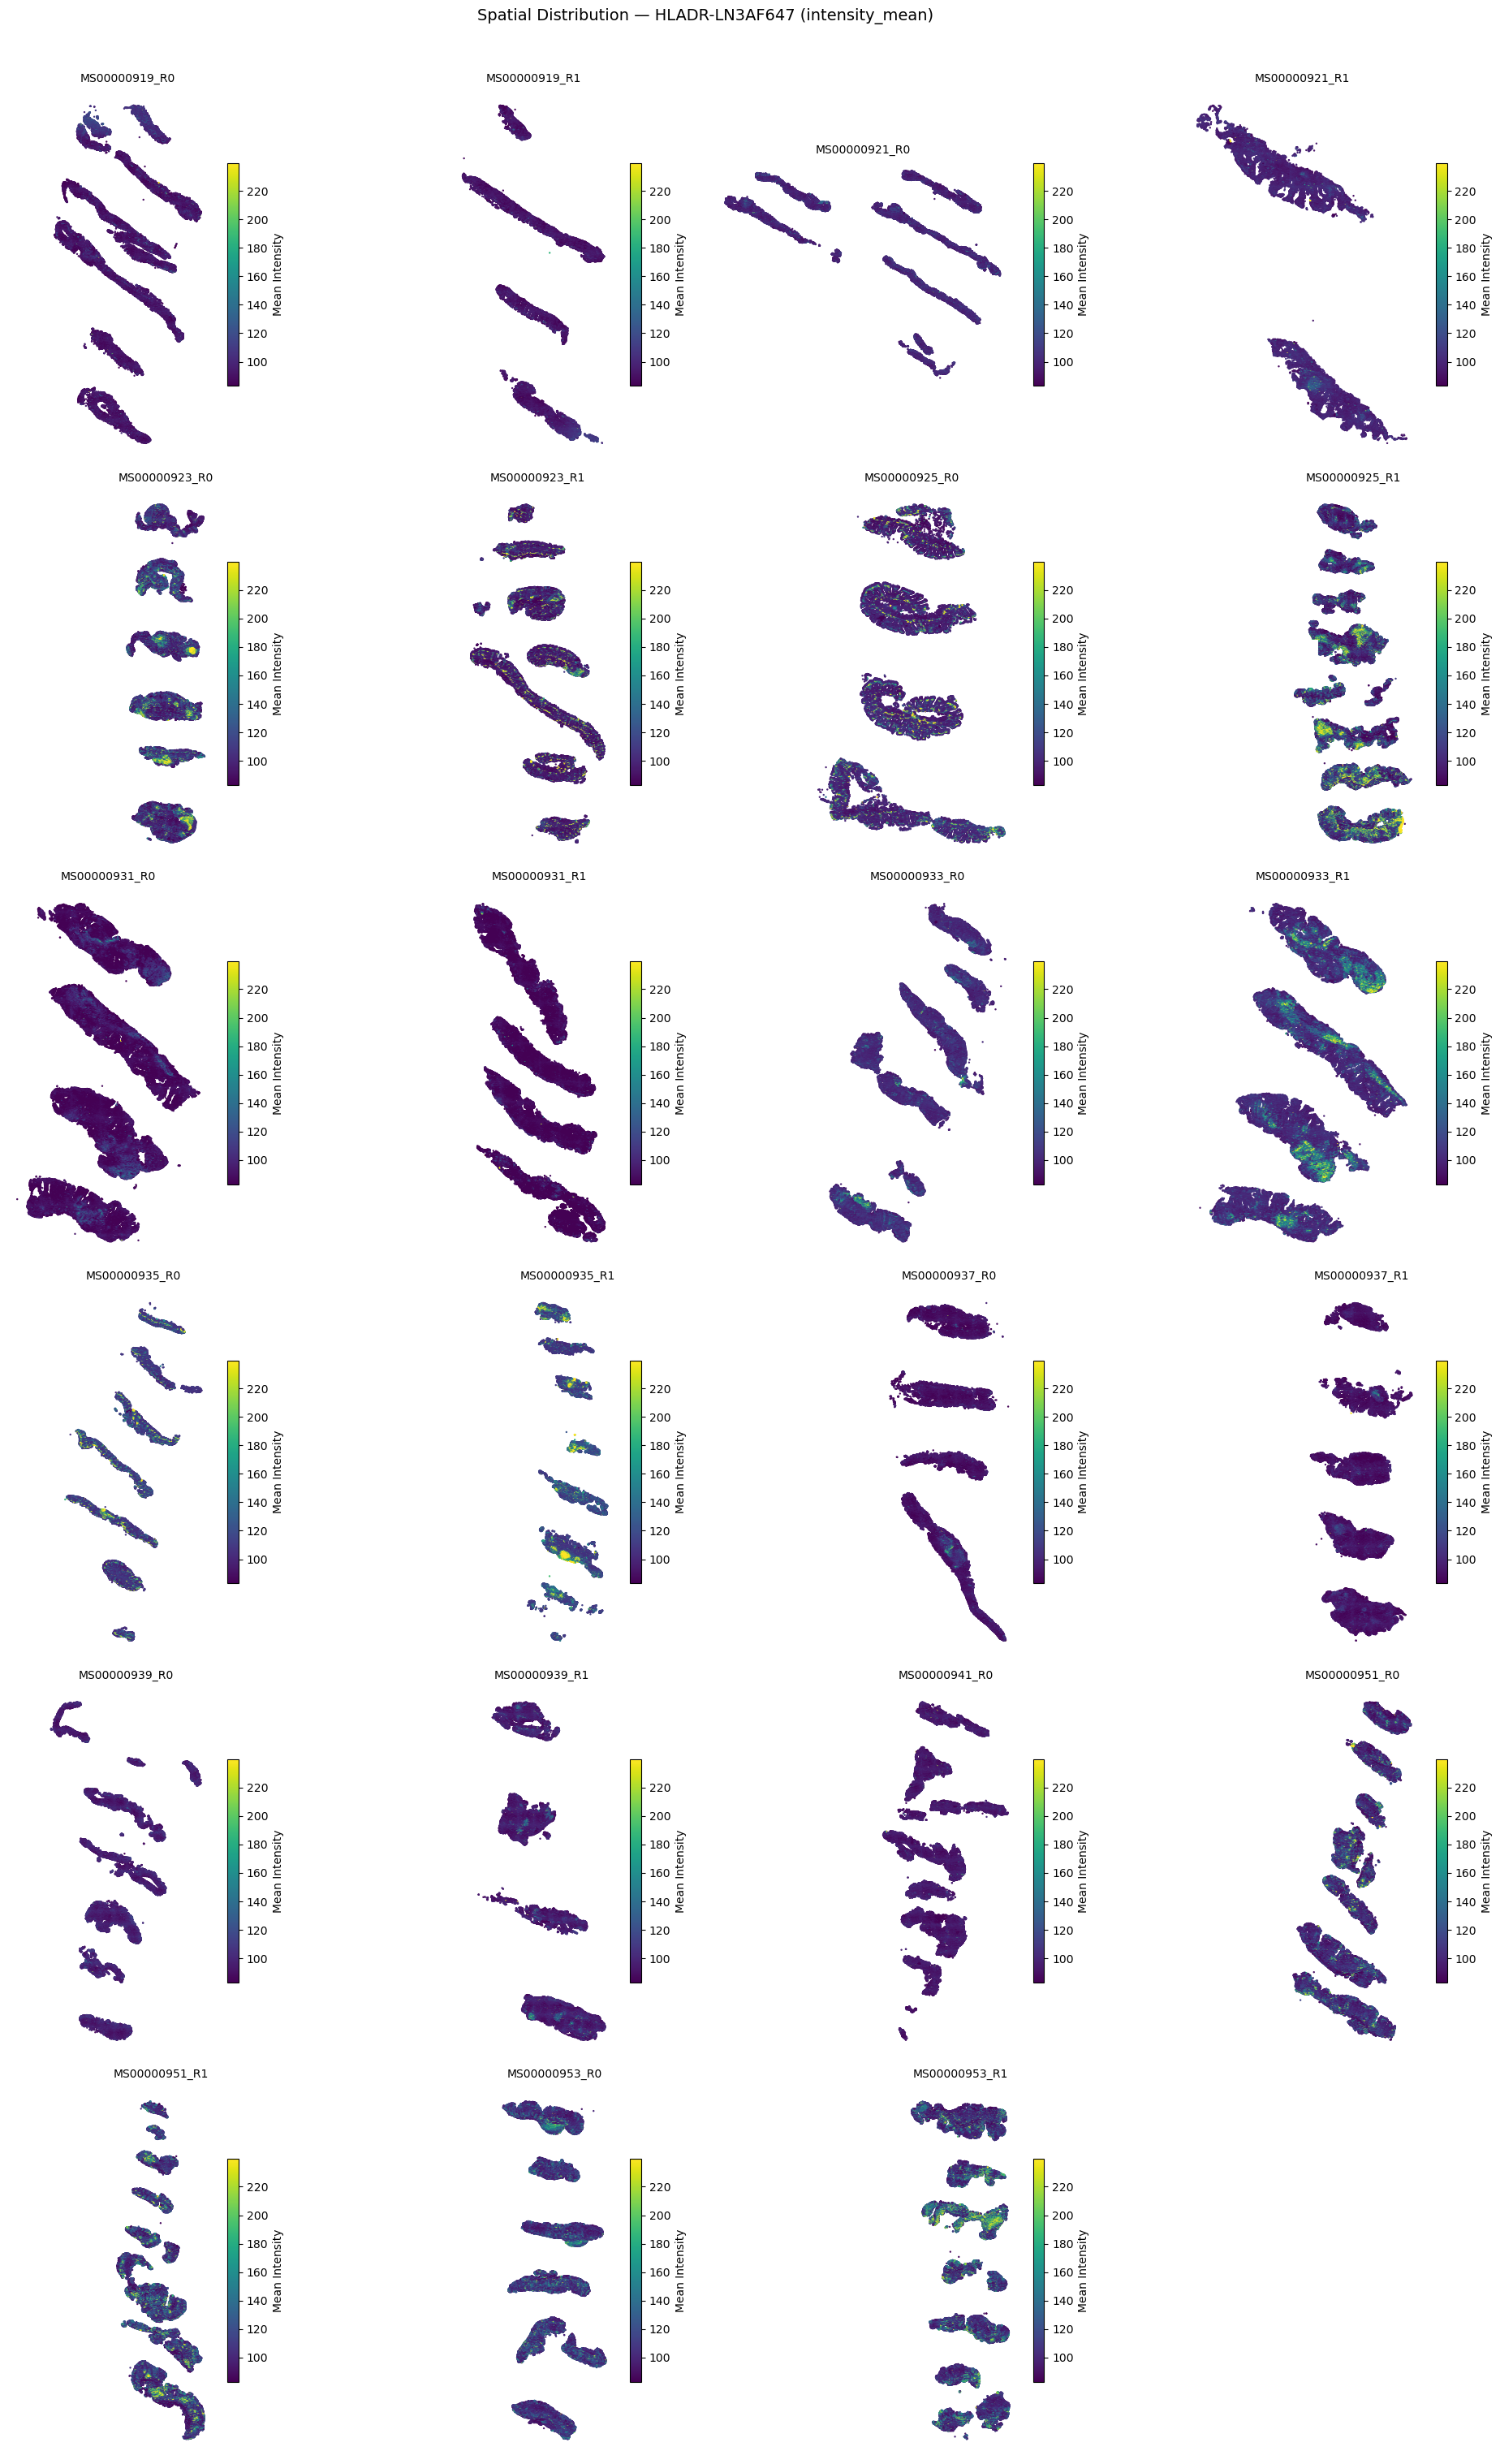

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import math

# --- Configuration ---
MARKER = "HLADR-LN3AF647"
LAYER = "intensity_mean"
CMAP = "viridis"
POINT_SIZE = 0.5
COLS = 4

# --- Setup ---
sample_ids = adata_filtered.obs['sample_id'].unique()
n_samples = len(sample_ids)
n_cols = min(COLS, n_samples)
n_rows = math.ceil(n_samples / n_cols)

# Get intensity values for the chosen marker
marker_idx = list(adata_filtered.var['marker_name']).index(MARKER)
layer = adata_filtered.layers[LAYER]

# Handle sparse or dense matrix
if hasattr(layer, 'toarray'):
    intensity = np.asarray(layer[:, marker_idx].toarray()).flatten()
else:
    intensity = np.asarray(layer[:, marker_idx]).flatten()

# Clip to 2nd–98th percentile to handle outliers
vmin, vmax = np.percentile(intensity, [2, 98])

# --- Plot ---
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
axes = axes.flatten()

for i, sample in enumerate(sample_ids):
    ax = axes[i]
    mask = (adata_filtered.obs['sample_id'] == sample).values
    x = adata_filtered.obs.loc[mask, 'x'].values
    y = adata_filtered.obs.loc[mask, 'y'].values
    c = intensity[mask]

    sc_plot = ax.scatter(x, y, c=c, cmap=CMAP, s=POINT_SIZE,
                         vmin=vmin, vmax=vmax, rasterized=True)
    ax.set_title(sample, fontsize=10)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.colorbar(sc_plot, ax=ax, shrink=0.6, label='Mean Intensity')

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f"Spatial Distribution — {MARKER} ({LAYER})", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"spatial_{MARKER}_{LAYER}.pdf", dpi=150, bbox_inches='tight')
plt.show()